Importing Libraries and LLM Setup

In [1]:
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from typing import TypedDict, List, Dict, Optional, Literal
from langgraph.graph import StateGraph, END

In [2]:
import os
import sys
sys.path.append(os.path.abspath(".."))

In [3]:
from agent.llm import call_llm, call_structured_llm
from agent.states import GlobalState

### Design Stage
1. Service Decomposition: Breaking down the system into microservices or modules based on functionality and domain boundaries.
2. Database Design: Choosing database types and products based on data needs and constraints.
3. API Structuring: Defining API endpoints, their inputs/outputs.
4. Infrastructure Planning: Selecting cloud providers, services, and infrastructure components.
5. User Checkpoint: Reviewing the design decisions with the user to ensure alignment with requirements and expectations.
6. Design Aggregation: Combining the outputs from the above steps into a cohesive design state for implementation.

In [4]:
# ========= Design Graph States =========

class DesignState(GlobalState):
    services: Dict[str, Dict]
    database_schema: Dict[str, Dict]
    api_endpoints: Dict[str, Dict]
    infrastructure: Dict[str, Dict]
    
    approved: Optional[bool]
    rerun_node: Literal["services", "database", "api", "infrastructure", None]
    changes_requested: Optional[str]

In [5]:
# ========= Services Node =========

# Structured output models for service design
class ServiceComponent(BaseModel):
    name: str = Field(default="", description="Service or module name")
    responsibility: str = Field(default="", description="Primary business responsibility")
    owned_data: List[str] = Field(default_factory=list, description="Data entities primarily owned by this service")
    dependencies: List[str] = Field(default_factory=list, description="Other services this service depends on")
    key_patterns: List[str] = Field(default=list, description="Key design patterns used (e.g. JWT for auth, caching strategy)")

class ServiceDesignDetails(BaseModel):
    services: List[ServiceComponent] = Field(default_factory=list, description="Desciption of service or module design")
    reasoning: str = Field(default="", description="Why this fits the requirements and constraints")
    confidence: float = Field(default=0.0, ge=0.0, le=1.0, description="Overall confidence from 0 to 1")

class ServicesDesignOutput(BaseModel):
    service_design: ServiceDesignDetails

# Prompt template for service design
service_prompt = PromptTemplate.from_template(
    """You are a senior software architect.
Design the system (or update existing) into clear services or module boundaries.

Return practical and concise output grounded in the input.
Keep confidence between 0 and 1.

Architecture:
{architecture}

Tech Stack:
{tech_stack}

Requirements:
{requirements}

Constraints:
{constraints}

Existing Services:
{existing_services}

Changes Requested:
{changes_requested}"""
)

# Node function for service
def services_design_node(state: DesignState) -> Dict:
    prompt = service_prompt.format(
        architecture=state.get("architecture", {}),
        tech_stack=state.get("tech_stack", {}),
        requirements=state.get("requirements", {}),
        constraints=state.get("constraints", {}),
        existing_services=state.get("services", {}),
		changes_requested=state.get("changes_requested", ""),
    )
    result = call_structured_llm(ServicesDesignOutput, prompt)

    service_design = result.get("service_design", {})

    return {
        "services": service_design,
        "approved": None,  # Reset approval for next steps
		"rerun_node": None,  # Reset rerun node
		"changes_requested": None,  # Reset changes requested
    }

In [6]:
# Example usage
services_design_node({
    "requirements": {
        "problem": "Build a social media app for pet owners.",
        "users": ["pet owners"],
        "features": ["pet profiles", "photo sharing", "social connections"],
        "scale_hint": "10,000 daily active users",
        "domain": "social media"
    },
    "constraints": {
        "scale": "10,000 daily active users",
        "latency": "unknown",
        "budget": "unknown",
        "team_size": "unknown",
        "security": "unknown"
    },
    "architecture": {
        "pattern": "modular_monolith",
        "reasoning": "Simple to operate at this scale while keeping module boundaries clear.",
        "confidence": 0.9
    },
    "tech_stack": {
        "frontend": "React",
        "backend": "FastAPI",
        "database": "PostgreSQL",
        "infra": "Kubernetes"
    }
})

{'services': {'services': [{'name': 'UserService',
    'responsibility': 'Manage user accounts, authentication, and pet owner profiles.',
    'owned_data': ['users', 'pet_owner_profiles'],
    'dependencies': ['AuthService'],
    'key_patterns': 'JWT for auth, Bcrypt for password hashing'},
   {'name': 'PostService',
    'responsibility': 'Handle photo sharing, posts, and comments.',
    'owned_data': ['posts', 'comments'],
    'dependencies': ['UserService', 'MediaService'],
    'key_patterns': 'S3 for media storage, Redis for caching recent posts'},
   {'name': 'ConnectionService',
    'responsibility': 'Manage social connections (following/followers) between users.',
    'owned_data': ['connections'],
    'dependencies': ['UserService'],
    'key_patterns': 'Graph database or adjacency list for efficient querying'},
   {'name': 'MediaService',
    'responsibility': 'Handle media uploads, processing, and storage.',
    'owned_data': ['media_files'],
    'dependencies': [],
    'key_p

In [6]:
# ========= Database Design Node =========

# Structured output models for database design
class DatabaseTable(BaseModel):
    name: str = Field(default="", description="Table name")
    desciption: str = Field(default="", description="Concise description of the table's purpose and which service owns it")
    fields: List[str] = Field(default_factory=list, description="list of core tables fields. format: id: uuid, pk")
    relations: List[str] = Field(default_factory=list, description="list of relationships to other tables. format: follows.user_id -> users.id")

class DatabaseDesignDetails(BaseModel):
    tables: List[DatabaseTable]
    reasoning: str = Field(default="", description="Concise overall schema rationale.")
    confidence: float = Field(default=0.0, description="Overall confidence from 0 to 1")

class DatabaseDesignOutput(BaseModel):
    database_design: DatabaseDesignDetails

# Prompt template for database design
db_prompt = PromptTemplate.from_template(
    """You are a senior backend architect.
Design a complete database schema (or update existing) from services and constraints.

For each service's owned_data, create the necessary tables.
Every table needs: a primary key, core fields, and foreign keys where relevant.
Keep it concise — no over-engineering.

Return practical and comprehensive schema grounded in the input.

Services:
{services}

Database Stack:
{db_stack}

Constraints:
{constraints}

Existing Database Schema:
{existing_database_schema}

Changes Requested:
{changes_requested}"""
)

# Node function for database design
def db_node(state: DesignState) -> Dict:
    db_stack = state.get("tech_stack", {}).get("database", {})
    
    prompt = db_prompt.format(
        services=state.get("services", {}),
        db_stack={
			"name": db_stack.get("name", "unknown"),
            "type": db_stack.get("type", "relational"), # Default to relational if not specified
            "orm": db_stack.get("orm", "unknown")
		},
        constraints=state.get("constraints", {}),
        existing_database_schema=state.get("database_schema", {}),
		changes_requested=state.get("changes_requested", "")
    )
    result = call_structured_llm(DatabaseDesignOutput, prompt)
    
    db_design = result.get("database_design", {})

    return {
        "database_schema": db_design,
    }

In [59]:
# Example usage
db_node({
    "services": {
        "services": [
            {
                "name": "User Service",
                "responsibility": "User auth and profile management",
                "owned_data": ["users", "sessions"],
                "dependencies": [],
                "key_patterns": "JWT auth"
            },
            {
                "name": "Social Service",
                "responsibility": "Follow graph and feed relationships",
                "owned_data": ["follows", "feeds"],
                "dependencies": ["User Service"],
                "key_patterns": "fan-out on write"
            }
        ],
        "reasoning": "Split by clear domain boundaries.",
        "confidence": 0.85
    },
    "tech_stack": {
		"database": {
			"type": "relational",
			"name": "PostgreSQL",
			"orm": "Prisma",
			"reasoning": "Relational DB fits well with structured data and relationships.",
		}
	},
    "constraints": {
        "scale": "10,000 daily active users",
        "latency": "p95 < 250ms",
        "budget": "moderate",
        "team_size": "small",
        "security": "standard auth + encrypted storage"
    }
})

{'database_design': {'tables': [{'name': 'users',
    'desciption': 'User authentication and profile management. Owned by User Service.',
    'fields': ['id: uuid, pk',
     'email: varchar, unique',
     'password_hash: varchar',
     'created_at: timestamp',
     'updated_at: timestamp'],
    'relations': []},
   {'name': 'sessions',
    'desciption': 'User session management for authentication. Owned by User Service.',
    'fields': ['id: uuid, pk',
     'user_id: uuid, fk -> users.id',
     'refresh_token: varchar, unique',
     'expires_at: timestamp',
     'created_at: timestamp'],
    'relations': ['user_id -> users.id']},
   {'name': 'follows',
    'desciption': 'Follower graph. Owned by Social Service.',
    'fields': ['id: uuid, pk',
     'follower_id: uuid, fk -> users.id',
     'following_id: uuid, fk -> users.id',
     'created_at: timestamp'],
    'relations': ['follower_id -> users.id', 'following_id -> users.id']},
   {'name': 'feeds',
    'desciption': 'User-specific f

In [7]:
# ======== API Design Node =========

# Structured output models for API design
class ApiEndpoint(BaseModel):
    name: str = ""
    purpose: str = ""
    base_route: str = Field(description="API base route involving child endpoints")

class ApiDesignOutput(BaseModel):
    api_design: List[ApiEndpoint] = Field(default_factory=list)
    frontend_notes: str = Field(default="", description="Notes for frontend integration, involving workflows and API client design")
    reasoning: str = Field(default="", description="Concise overall API design rationale.")
    confidence: float = Field(default=0.0, description="Overall confidence from 0 to 1")

# Prompt template for API design
api_prompt = PromptTemplate.from_template(
    """You are a senior API designer.
Design APIs (or update existing) from the services and constraints.

Return practical and concise output grounded in the input.

Services:
{services}

Constraints:
{constraints}

Existing APIs:
{existing_apis}

Changes Requested:
{changes_requested}"""
)

# Node function for API design
def api_node(state: DesignState) -> Dict:
    prompt = api_prompt.format(
        services=state.get("services", {}),
		constraints=state.get("constraints", {}),
		existing_apis=state.get("api_endpoints", {}),
		changes_requested=state.get("changes_requested", "")
    )
    
    result = call_structured_llm(ApiDesignOutput, prompt)

    return {
        "api_endpoints": result,
    }

In [10]:
# Example usage
api_node({
    "services": {
        "services": [
            {
                "name": "User Service",
                "responsibility": "Auth and profile",
                "owned_data": ["users", "sessions"],
                "dependencies": [],
                "key_patterns": "JWT"
            },
            {
                "name": "Media Service",
                "responsibility": "Photo upload and retrieval",
                "owned_data": ["media_assets"],
                "dependencies": ["User Service"],
                "key_patterns": "presigned URL uploads"
            }
        ],
        "reasoning": "API boundaries map to service boundaries.",
        "confidence": 0.84
    },
    "constraints": {
        "scale": "10,000 daily active users",
        "latency": "p95 < 250ms",
        "security": "token-based auth"
    }
})

{'api_endpoints': {'api_design': [{'name': 'User Profile API',
    'purpose': 'Handles user authentication and profile management.',
    'base_route': '/users'},
   {'name': 'Media API',
    'purpose': 'Enables photo uploads and retrieval.',
    'base_route': '/media'}],
  'frontend_notes': 'The User Profile API should expose endpoints for user registration, login, logout, and profile updates. The Media API should provide endpoints for uploading photos (potentially returning presigned URLs for direct client uploads) and retrieving media assets. Both APIs should implement token-based authentication, validating tokens on each request. Consider implementing pagination for endpoints that return lists of resources to manage scale effectively.',
  'reasoning': "The API design aligns with the provided service boundaries, ensuring that each API corresponds to a specific service's responsibility. The User Profile API will manage authentication and user data, while the Media API will handle medi

In [8]:
# ======== Infrastructure Planning Node =========

# Structured output models for infrastructure planning
class InfrastructureDetails(BaseModel):
    cloud: str = ""
    services: List[str] = Field(default_factory=list)
    deployment: str = ""
    reasoning: str = ""
    confidence: float = 0.0

class InfrastructureOutput(BaseModel):
    infrastructure: InfrastructureDetails

# Prompt template for infrastructure planning
infra_prompt = PromptTemplate.from_template(
    """You are a senior cloud architect.
Design infrastructure (or update existing) from tech stack and constraints.

Return practical and concise output grounded in the input.

Services:
{services}

Constraints:
{constraints}

Existing Infrastructure:
{existing_infrastructure}

Changes Requested:
{changes_requested}"""
)

# Node function for infrastructure planning
def infra_node(state: DesignState) -> Dict:
    prompt = infra_prompt.format(
        services=state.get("services", {}),
        constraints=state.get("constraints", {}),
        existing_infrastructure=state.get("infrastructure", {}),
		changes_requested=state.get("changes_requested", "")
    )
    
    result = call_structured_llm(InfrastructureOutput, prompt)

    return {
        "infrastructure": result.get("infrastructure", {}),
    }

In [41]:
# Example usage
infra_node({
    "services": {
        "services": [
            {
                "name": "User Service",
                "responsibility": "Authentication and user profile",
                "owned_data": ["users"],
                "dependencies": [],
                "key_patterns": "stateless API"
            },
            {
                "name": "Media Service",
                "responsibility": "Media upload and retrieval",
                "owned_data": ["media_assets"],
                "dependencies": ["User Service"],
                "key_patterns": "object storage + CDN"
            }
        ],
        "reasoning": "Infrastructure should support API and media workloads.",
        "confidence": 0.83
    },
    "constraints": {
        "scale": "10,000 daily active users",
        "latency": "p95 < 250ms",
        "budget": "moderate",
        "team_size": "small",
        "security": "private networking and secrets management"
    }
})

{'infrastructure': {'cloud': 'AWS',
  'services': ['User Service', 'Media Service'],
  'deployment': 'Kubernetes',
  'reasoning': "AWS offers a wide range of services that cater to the needs of the User and Media services. Kubernetes provides a scalable and robust platform for deploying and managing containerized applications, which aligns with the 'stateless API' and 'object storage + CDN' patterns. The use of AWS services like S3 for object storage, CloudFront for CDN, and EKS for Kubernetes aligns with a moderate budget and small team size, while offering robust security features like private networking and secrets management.",
  'confidence': 0.85}}

In [9]:
# ======== User Checkpoint Node =========

def user_checkpoint_node(state: DesignState) -> Dict:
	# This node can be used to pause the graph execution and allow the user to review the current design state
	services = state.get("services", {})
	database = state.get("database_schema", {})
	api = state.get("api_endpoints", {})
	infrastructure = state.get("infrastructure", {})

	print("\nUser Checkpoint - Review the current design state:")
	print("Services:", services)
	print("Database Schema:", database)
	print("API Endpoints:", api)
	print("Infrastructure:", infrastructure)

	approved = input("Do you approve all the current design states? (yes/no): ").strip().lower() == "yes"

	if not approved:
		rerun_node = input("Which node do you want to rerun? (services/api/database/infrastructure): ").strip().lower()
		changes_requested = input("What changes do you want to request? (Provide a brief description): ").strip()

		return {
			"approved": False,
			"rerun_node": rerun_node if rerun_node in ["services", "database", "api", "infrastructure"] else None,
			"changes_requested": changes_requested,
		}

	return {
		"approved": True,
		"rerun_node": None,
		"changes_requested": None,
	}

In [10]:
# ========= Design Aggregation Node =========

def design_aggregation_node(state: DesignState) -> Dict:
	# This node aggregates the final design decisions into a comprehensive design bundle that can be used for implementation or documentation
	design_bundle = {
		"services": state.get("services", {}),
		"database_schema": state.get("database_schema", {}),
		"api_endpoints": state.get("api_endpoints", {}),
		"infrastructure": state.get("infrastructure", {}),
	}

	return {
		"design_bundle": design_bundle
	}

In [11]:
# ======== Design Router Node =========

def post_checkpoint_router(state: DesignState):
	if state.get("approved") is False:
		# If not approved, route to rerun node back
		return state.get("rerun_node")
	
	# If approved or no rerun requested, proceed to next steps or end
	return "aggregation"

def post_node_router(state: DesignState):
	if state.get("approved") is False:
		# rerun node - single node execution after user checkpoint
		return "rerun"
	
	# parallel node execution after user checkpoint - wait for all nodes to complete
	return "design_parallel"

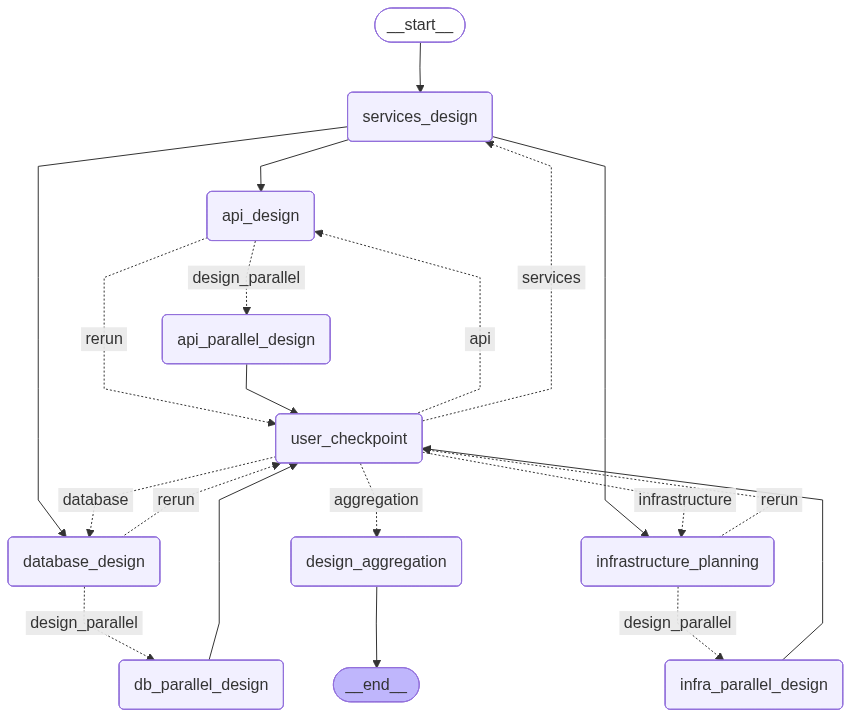

In [12]:
# =========== Graph Construction ===========

design_graph = StateGraph(DesignState)

design_graph.add_node("services_design", services_design_node)
design_graph.add_node("database_design", db_node)
design_graph.add_node("api_design", api_node)
design_graph.add_node("infrastructure_planning", infra_node)

# Dummy nodes for parallel design nodes before user checkpoint
design_graph.add_node("db_parallel_design", lambda state: {})
design_graph.add_node("api_parallel_design", lambda state: {})
design_graph.add_node("infra_parallel_design", lambda state: {})

design_graph.add_node("user_checkpoint", user_checkpoint_node)
design_graph.add_node("design_aggregation", design_aggregation_node)

design_graph.set_entry_point("services_design")

design_graph.add_edge("services_design", "database_design")
design_graph.add_edge("services_design", "api_design")
design_graph.add_edge("services_design", "infrastructure_planning")

# User checkpoint after all parallel design nodes execute to allow review and potential rerun (parallel execution)
design_graph.add_edge(
    ["db_parallel_design", "api_parallel_design", "infra_parallel_design"],
    "user_checkpoint"
)

# When any node reruns, it goes to user checkpoint (single execution path in case of rerun)
design_graph.add_conditional_edges(
    "database_design", post_node_router,
    {
        "rerun": "user_checkpoint",
        "design_parallel": "db_parallel_design",
    }
)
design_graph.add_conditional_edges(
    "api_design", post_node_router,
    {
        "rerun": "user_checkpoint",
        "design_parallel": "api_parallel_design",
    }
)
design_graph.add_conditional_edges(
    "infrastructure_planning", post_node_router,
    {
        "rerun": "user_checkpoint",
        "design_parallel": "infra_parallel_design",
    }
)

design_graph.add_edge("design_aggregation", END)

design_graph.add_conditional_edges(
    "user_checkpoint",
    post_checkpoint_router,
    {
        "services": "services_design",
        "database": "database_design",
        "api": "api_design",
        "infrastructure": "infrastructure_planning",
        "aggregation": "design_aggregation",  # If user approves and wants to proceed to aggregation
    }
)

design_stage = design_graph.compile()
design_stage

In [16]:
# Example usage of the design stage
design_report = design_stage.invoke({
	"requirements": {
        "problem": "Build a social media app for pet owners.",
        "users": ["pet owners"],
        "features": ["pet profiles", "photo sharing", "social connections"],
        "scale_hint": "10,000 daily active users",
        "domain": "social media"
    },
    "constraints": {
        "scale": "10,000 daily active users",
        "latency": "unknown",
        "budget": "unknown",
        "team_size": "unknown",
        "security": "unknown"
    },
    'architecture': {
        'pattern': 'modular_monolith',
		'modules': ['User Authentication', 'Pet Profiles', 'Photo/Video Upload & Storage', 'Feed Generation', 'Social Connections (Follow/Friend)', 'Notifications'],
		'reasoning': 'A modular monolith is suitable for the initial scale of 10,000 daily active users. It provides better organization than a traditional monolith and is simpler to manage than microservices at this stage. The modules are distinct but can coexist within a single deployable unit. Microservices would introduce unnecessary complexity and operational overhead for this user base. A full monolith might become difficult to manage as features grow.',
		'confidence': 0.9
	},
	'tech_stack': {
    	'frontend': {
			'language': 'TypeScript',
			'framework': 'React',
			'reasoning': 'React allows for efficient UI development and management of complex state, suitable for a dynamic social media feed and profiles. TypeScript enhances maintainability and scalability for a growing application.'
		},
		'backend': {
			'language': 'Python',
			'framework': 'FastAPI',
			'reasoning': 'Python with FastAPI offers excellent performance, rapid development, and built-in support for asynchronous operations, which is beneficial for microservices handling multiple requests like photo uploads and notifications. Its extensive libraries also support various functionalities.'
		},
		'database': {
      		'type': 'Document',
			'name': 'MongoDB',
			'orm': '',
			'reasoning': 'MongoDB is a flexible NoSQL database well-suited for evolving data structures common in social media apps, such as user profiles and feed content. Its scalability and performance can handle the demands of 10,000 daily active users.'
		},
		'infra': {
			'provider': 'AWS',
			'services': ['Docker', 'Kubernetes', 'AWS S3', 'REST APIs'],
			'reasoning': 'AWS provides a robust and scalable cloud infrastructure. Docker and Kubernetes will facilitate containerization and orchestration of microservices. AWS S3 is ideal for photo storage. REST APIs are standard for microservice communication.'
    	},
		'overall_reasoning': '',
		'confidence': 0.0
  	}
})


User Checkpoint - Review the current design state:
Services: {'services': [{'name': 'User Authentication', 'responsibility': 'Manage user registration, login, and session management.', 'owned_data': ['User accounts', 'Credentials'], 'dependencies': [], 'key_patterns': 'JWT for authentication'}, {'name': 'Pet Profiles', 'responsibility': 'Manage pet information and associated owner details.', 'owned_data': ['Pet profiles', 'Owner details'], 'dependencies': ['User Authentication'], 'key_patterns': ''}, {'name': 'Photo/Video Upload & Storage', 'responsibility': 'Handle uploading, processing, and storing of photos and videos.', 'owned_data': ['Media files', 'Metadata'], 'dependencies': ['User Authentication'], 'key_patterns': 'AWS S3 for storage'}, {'name': 'Feed Generation', 'responsibility': 'Aggregate and serve content to user feeds.', 'owned_data': ['Feed items'], 'dependencies': ['Pet Profiles', 'Social Connections (Follow/Friend)', 'Photo/Video Upload & Storage'], 'key_patterns': 'C

In [17]:
for item in design_report['design_bundle'].items():
	print(f"{item[0]}: {item[1]}\n")

services: {'services': [{'name': 'User Authentication', 'responsibility': 'Manage user registration, login, and session management.', 'owned_data': ['User accounts', 'Credentials'], 'dependencies': [], 'key_patterns': 'JWT for authentication'}, {'name': 'Pet Profiles', 'responsibility': 'Manage pet information and associated owner details.', 'owned_data': ['Pet profiles', 'Owner details'], 'dependencies': ['User Authentication'], 'key_patterns': ''}, {'name': 'Photo/Video Upload & Storage', 'responsibility': 'Handle uploading, processing, and storing of photos and videos.', 'owned_data': ['Media files', 'Metadata'], 'dependencies': ['User Authentication'], 'key_patterns': 'AWS S3 for storage'}, {'name': 'Feed Generation', 'responsibility': 'Aggregate and serve content to user feeds.', 'owned_data': ['Feed items'], 'dependencies': ['Pet Profiles', 'Social Connections (Follow/Friend)', 'Photo/Video Upload & Storage'], 'key_patterns': 'Caching for performance'}, {'name': 'Social Connectio